# AmsterdamUMCdb Exploration

## Capstone Goal
Predict successful weaning from mechanical ventilation using time-series deep learning models.

## Objectives
- Understand database structure
- Identify ventilation-related tables
- Find extubation events
- Explore physiological measurements
- Understand timestamps and patient identifiers

### Imports

In [2]:
import pandas as pd
import numpy as np
from google.cloud import bigquery
import matplotlib.pyplot as plt

### Retrieving Google Project Id

In [3]:
client = bigquery.Client()

print("Connected to BigQuery")

Connected to BigQuery


In [4]:
# sets *your* project id
PROJECT_ID = "capstoneweaningprediction" #@param {type:"string"}

# Sets the default BigQuery dataset for accessing AmsterdamUMCdb

If you have received instructions to use a specific BigQuery instance, change the default settings here. Otherwise use these default values.

In [5]:
# sets default dataset for AmsterdamUMCdb
DATASET_PROJECT_ID = 'amsterdamumcdb' #@param {type:"string"}
DATASET_ID = 'version1_5_0' #@param {type:"string"}
LOCATION = 'eu' #@param {type:"string"}

# Provide your credentials to access the AmsterdamUMCdb dataset on Google BigQuery
Authenticate your credentials with Google Cloud Platform and set your default Google Cloud Project ID as an environment variable for running query jobs.

1. Run the cell. The `Allow this notebook to access your Google credentials?` prompt appears. Select `Allow`.
2. In the `Sign in - Google Accounts` dialog, use the account you registered during the AmsterdamUMCdb application process and select `Allow` again.

In [6]:
import os
from google.colab import auth

# all libraries check this environment variable, so set it:
os.environ["GOOGLE_CLOUD_PROJECT"] = PROJECT_ID

auth.authenticate_user()
print('Authenticated')

Authenticated


# Enable data table display

Colab includes the `google.colab.data_table` package that can be used to display Pandas dataframes as an interactive data table (default limits: `max_rows = 20000`, `max_columns = 20`). This is especially useful when exploring the  tables or dictionary from AmsterdamUMCdb. It can be enabled with:

In [7]:
%load_ext google.colab.data_table
from google.colab.data_table import DataTable

# change default limits:
DataTable.max_columns = 50
DataTable.max_rows = 80000


## Set the default query job configuration for magics

In [8]:
%load_ext bigquery_magics
from bigquery_magics import bigquery_magics
from google.cloud import bigquery

# sets the default query job configuration
def_config = bigquery.job.QueryJobConfig(default_dataset=DATASET_PROJECT_ID + "." + DATASET_ID)
bigquery_magics.context.default_query_job_config = def_config

## Query the `person` table and copy the data to the `persons` Pandas dataframe:

The `person` table contains a record for each patient in AmsterdamUMCdb.

Since this is a relatively small table, it is acceptable to use `SELECT *`.

**Note**: Should an error occur while running the query, please see
the AmsterdamUMCdb BigQuery [Frequently Asked Questions](https://github.com/AmsterdamUMC/AmsterdamUMCdb/wiki/bigquery#faq).

In [9]:
%%bigquery person
SELECT * FROM `amsterdamumcdb.version1_5_0.person`;

Query is running:   0%|          |

Downloading:   0%|          |


## Set the default query job configuration for google-cloud-bigquery client

In [10]:
from google.cloud import bigquery

# BigQuery requires a separate config to prevent the 'BadRequest: 400 Cannot explicitly modify anonymous table' error message
job_config = bigquery.job.QueryJobConfig()

# sets default client settings by re-using the previously defined config
client = bigquery.Client(project=PROJECT_ID, location=LOCATION, default_query_job_config=def_config)

### Section 1 Database Overview

In [11]:
# Query: table sizes
query = """
SELECT table_id AS table_name, row_count
FROM `amsterdamumcdb.version1_5_0.__TABLES__`
ORDER BY row_count DESC
"""
tables_df = client.query(query).to_dataframe()
tables_df.head(20)

,table_name,row_count
0,measurement,1342825459
1,concept_ancestor,72374967
2,observation,66243172
3,concept_relationship,38570316
4,procedure_occurrence,21159406
5,concept,6071642
6,drug_exposure,5872023
7,concept_synonym,3339956
8,drug_strength,2981807
9,condition_occurrence,2320948


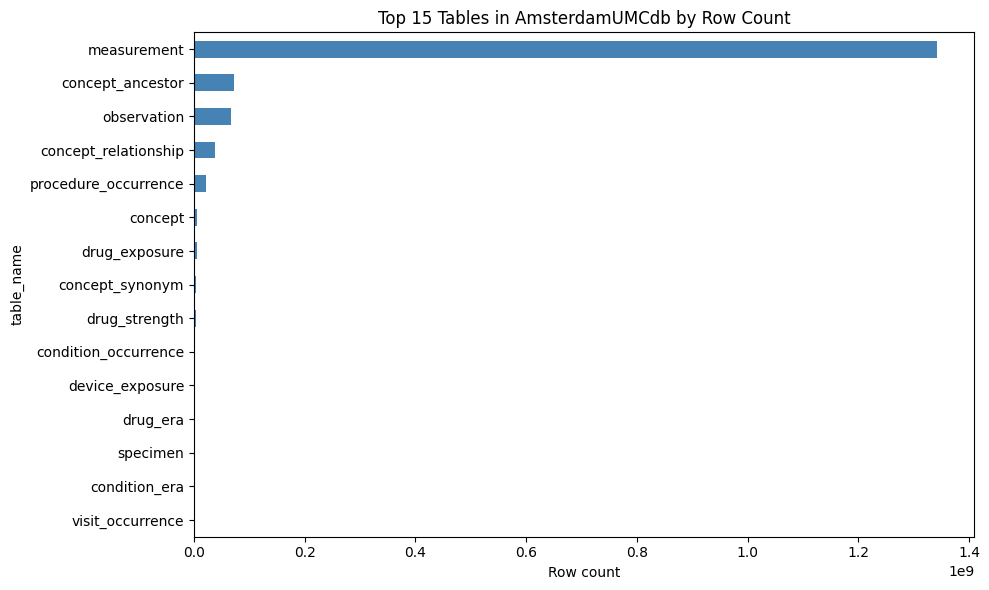

In [12]:
# Chart: top 15 tables
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
tables_df.head(15).plot(kind='barh', x='table_name', y='row_count',
                         ax=ax, color='steelblue', legend=False)
ax.set_title('Top 15 Tables in AmsterdamUMCdb by Row Count')
ax.set_xlabel('Row count')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Section 2 Patient Cohort baseline

In [13]:
# Query: cohort summary
query = """
SELECT
  COUNT(*) AS n_patients,
  ROUND(AVG(2020 - year_of_birth), 1) AS mean_age,
  SUM(CASE WHEN gender_concept_id = 8507 THEN 1 ELSE 0 END) AS n_male,
  SUM(CASE WHEN gender_concept_id = 8532 THEN 1 ELSE 0 END) AS n_female
FROM `amsterdamumcdb.version1_5_0.person`
"""
cohort_summary = client.query(query).to_dataframe()
cohort_summary

,n_patients,mean_age,n_male,n_female
0,20109,72.2,12799,6845


In [14]:
# Query: age distribution
query = """
SELECT (2020 - year_of_birth) AS age
FROM `amsterdamumcdb.version1_5_0.person`
WHERE year_of_birth IS NOT NULL
"""
age_df = client.query(query).to_dataframe()

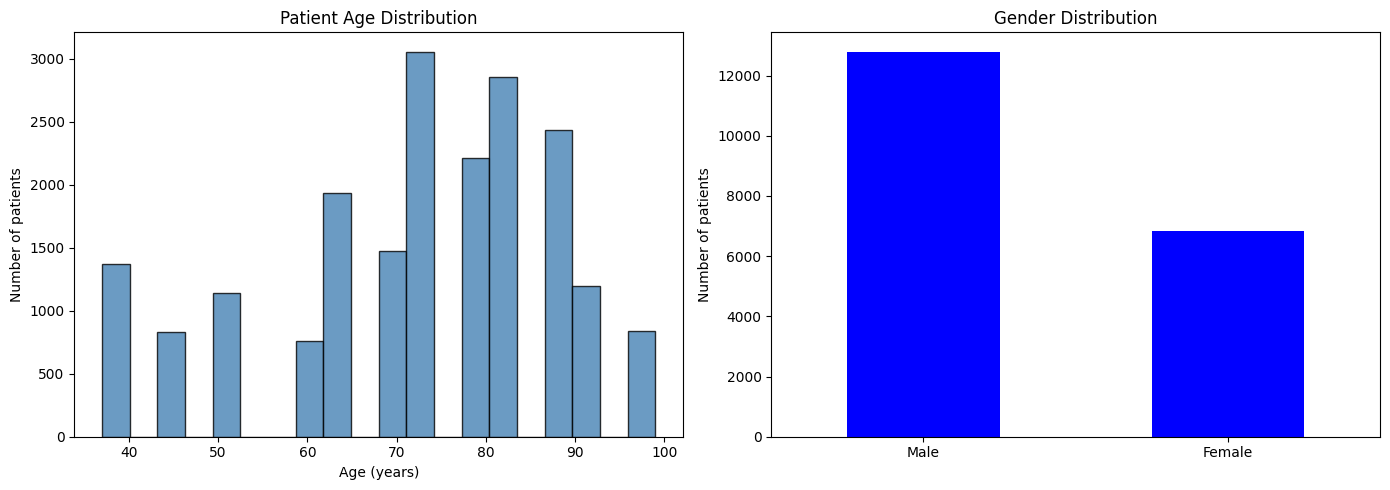

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age histogram
axes[0].hist(
    age_df['age'],
    bins=20,
    color='steelblue',
    edgecolor='black',
    alpha=0.8
)

axes[0].set_title('Patient Age Distribution')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Number of patients')

# Gender distribution
gender_counts = cohort_summary[['n_male', 'n_female']].T
gender_counts.columns = ['count']
gender_counts.index = ['Male', 'Female']

gender_counts.plot(
    kind='bar',
    ax=axes[1],
    color=['blue', 'orange'],
    legend=False
)

axes[1].set_title('Gender Distribution')
axes[1].set_ylabel('Number of patients')
axes[1].set_xticklabels(gender_counts.index, rotation=0)

plt.tight_layout()
plt.show()

The cohort is predominantly older adults, with most patients falling between 65 and 90 years of age, which is expected in ICU populations requiring mechanical ventilation. The gender distribution shows a higher proportion of male patients compared to female patients in the dataset.